# Klasifikasi Banana
## Data Understanding


In [2]:
!pip install pandas matplotlib pillow numpy

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.0 MB 8.2 MB/s eta 0:00:02
   -- ------------------------------------- 0.8/11.0 MB 1.9 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/11.0 MB 2.9 MB/s eta 0:00:04
   ------------ --------------------------- 3.4/11.0 MB 4.6 MB/s eta 0:00:02
   -------------------- ------------------- 5.5/11.0 MB 5.9 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.0 MB 6.4 MB/s eta 0:00:01
   --------------------------------- ------ 9.2/11.0 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------  10.7/11.0 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 6.9 MB/s  0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ----

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import numpy as np
import pandas as pd

# --- 1. Tentukan path dataset ---
dataset_path = "dataset"  # Sesuaikan jika folder berbeda

train_fresh = os.path.join(dataset_path, "train", "freshbanana")
train_rotten = os.path.join(dataset_path, "train", "rottenbanana")
test_fresh = os.path.join(dataset_path, "test", "freshbanana")
test_rotten = os.path.join(dataset_path, "test", "rottenbanana")

In [4]:
# --- 2. Hitung jumlah gambar per folder ---
def count_images(folder_path):
    if not os.path.exists(folder_path):
        return 0
    return len([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

train_fresh_count = count_images(train_fresh)
train_rotten_count = count_images(train_rotten)
test_fresh_count = count_images(test_fresh)
test_rotten_count = count_images(test_rotten)

total_train = train_fresh_count + train_rotten_count
total_test = test_fresh_count + test_rotten_count
total_all = total_train + total_test

print("📊 STATISTIK JUMLAH GAMBAR:")
print(f"Train - Fresh Banana: {train_fresh_count}")
print(f"Train - Rotten Banana: {train_rotten_count}")
print(f"Test - Fresh Banana: {test_fresh_count}")
print(f"Test - Rotten Banana: {test_rotten_count}")
print("-" * 40)
print(f"Total Train: {total_train}")
print(f"Total Test: {total_test}")
print(f"Total Keseluruhan: {total_all}")

📊 STATISTIK JUMLAH GAMBAR:
Train - Fresh Banana: 1581
Train - Rotten Banana: 2224
Test - Fresh Banana: 381
Test - Rotten Banana: 530
----------------------------------------
Total Train: 3805
Total Test: 911
Total Keseluruhan: 4716


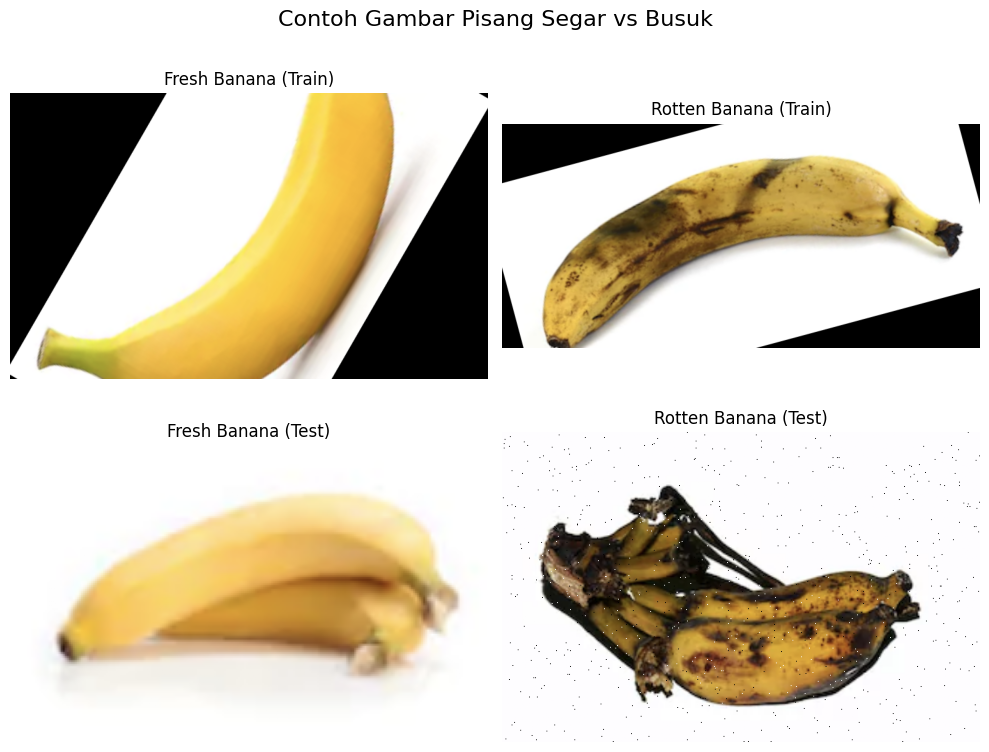

In [5]:
# --- 3. Tampilkan contoh gambar dari masing-masing kelas ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Contoh Gambar Pisang Segar vs Busuk", fontsize=16)

# Ambil satu gambar acak dari setiap folder
def get_random_image(folder):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not files:
        return None
    return os.path.join(folder, np.random.choice(files))

# Fresh Banana (Train)
img_path = get_random_image(train_fresh)
if img_path:
    img = mpimg.imread(img_path)
    axes[0, 0].imshow(img)
    axes[0, 0].set_title("Fresh Banana (Train)")
    axes[0, 0].axis('off')

# Rotten Banana (Train)
img_path = get_random_image(train_rotten)
if img_path:
    img = mpimg.imread(img_path)
    axes[0, 1].imshow(img)
    axes[0, 1].set_title("Rotten Banana (Train)")
    axes[0, 1].axis('off')

# Fresh Banana (Test)
img_path = get_random_image(test_fresh)
if img_path:
    img = mpimg.imread(img_path)
    axes[1, 0].imshow(img)
    axes[1, 0].set_title("Fresh Banana (Test)")
    axes[1, 0].axis('off')

# Rotten Banana (Test)
img_path = get_random_image(test_rotten)
if img_path:
    img = mpimg.imread(img_path)
    axes[1, 1].imshow(img)
    axes[1, 1].set_title("Rotten Banana (Test)")
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


📏 ANALISIS RESOLUSI GAMBAR:
Jumlah gambar yang dianalisis: 4716
Resolusi rata-rata: 511 x 377 piksel
Resolusi minimum: 174x128
Resolusi maksimum: 862x518
Format paling umum: PNG


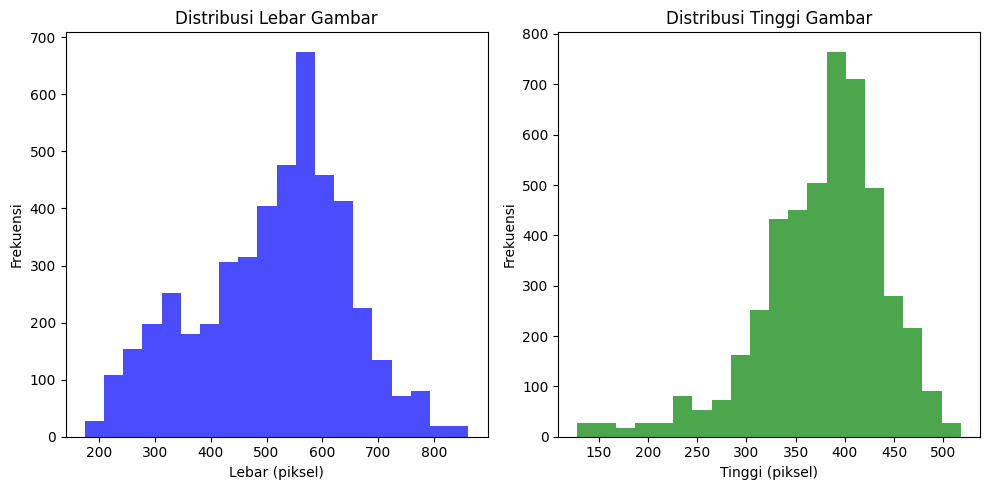

In [ ]:
# --- 4. Analisis Resolusi & Format Gambar ---
def analyze_images(folder_paths):
    resolutions = []
    formats = []
    for folder in folder_paths:
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for f in files:
            img_path = os.path.join(folder, f)
            try:
                with Image.open(img_path) as img:
                    resolutions.append(img.size)  # (width, height)
                    formats.append(img.format)
            except Exception as e:
                print(f"Error membaca {img_path}: {e}")
    return resolutions, formats

all_folders = [train_fresh, train_rotten, test_fresh, test_rotten]
resolutions, formats = analyze_images(all_folders)

# Konversi ke DataFrame untuk analisis lebih lanjut
df_res = pd.DataFrame(resolutions, columns=['Width', 'Height'])
df_res['Area'] = df_res['Width'] * df_res['Height']

print("\n📏 ANALISIS RESOLUSI GAMBAR:")
print(f"Jumlah gambar yang dianalisis: {len(resolutions)}")
print(f"Resolusi rata-rata: {df_res['Width'].mean():.0f} x {df_res['Height'].mean():.0f} piksel")
print(f"Resolusi minimum: {df_res['Width'].min()}x{df_res['Height'].min()}")
print(f"Resolusi maksimum: {df_res['Width'].max()}x{df_res['Height'].max()}")
print(f"Format paling umum: {pd.Series(formats).value_counts().index[0]}")

# Plot distribusi resolusi
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df_res['Width'], bins=20, color='blue', alpha=0.7)
plt.title('Distribusi Lebar Gambar')
plt.xlabel('Lebar (piksel)')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
plt.hist(df_res['Height'], bins=20, color='green', alpha=0.7)
plt.title('Distribusi Tinggi Gambar')
plt.xlabel('Tinggi (piksel)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()


In [7]:

# --- 5. Ringkasan Statistik ---
print("\n✅ RINGKASAN DATA UNDERSTANDING:")
print(f"• Dataset seimbang? {'Ya' if abs(train_fresh_count - train_rotten_count) < 50 else 'Tidak'}")
print(f"• Total gambar: {total_all}")
print(f"• Format utama: {pd.Series(formats).value_counts().index[0]}")
print(f"• Resolusi rata-rata: ~{int(df_res['Width'].mean())}x{int(df_res['Height'].mean())} piksel")
print(f"• Ada gambar dengan latar belakang non-putih? → Perlu verifikasi manual (tidak terdeteksi otomatis)")


✅ RINGKASAN DATA UNDERSTANDING:
• Dataset seimbang? Tidak
• Total gambar: 4716
• Format utama: PNG
• Resolusi rata-rata: ~511x376 piksel
• Ada gambar dengan latar belakang non-putih? → Perlu verifikasi manual (tidak terdeteksi otomatis)


## Preprocessing Data


In [8]:
!pip install tensorflow

  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/331.9 MB ? eta -:--:--
   ---------------------------------------- 1.8/331.9 MB 5.3 MB/s eta 0:01:03
    --------------------------------------- 4.2/331.9 MB 7.0 MB/s eta 0:00:47
    --------------------------------------- 5.8/331.9 MB 7.0 MB/s eta 0:00:47
    --------------------------------------- 6.3/331.9 MB 6.4 MB/s eta 0:00:51
    --------------------------------------- 6.8/331.9 MB 5.5 MB/s eta 0:00:59
    --------------------------------------- 7.3/331.9 MB 5.1 MB/s eta 0:01:04
    --------------------------------------- 7.9/331.9 MB 4.8 MB/s eta 0:01:08
   - -------------------------------------- 8.7/331.9 MB 4.6 MB/s eta 0:01:12
   - -------------------------------------- 9.2/331.9 MB 4.4 MB/s eta 0:01:14
   - -------------------------------------- 9.7/331.9 MB 4.2 MB/s eta 0:01:18
   - -----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 6.33.2 which is incompatible.


In [19]:
!pip install pandas numpy matplotlib pillow tensorflow scikit-learn opencv-python

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 6.7 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.0 MB 5.2 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 4.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.0 MB 4.5 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.0 MB 5.2 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 5.3 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 5.0 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.0 MB 4.8 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.0 MB 4.8 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 3.7 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.0 MB 3.6 MB/s eta 0:00:01
   -----------------------

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# --- 1. Tentukan path dataset ---
dataset_path = "dataset"
train_fresh = os.path.join(dataset_path, "train", "freshbanana")
train_rotten = os.path.join(dataset_path, "train", "rottenbanana")
test_fresh = os.path.join(dataset_path, "test", "freshbanana")
test_rotten = os.path.join(dataset_path, "test", "rottenbanana")


In [ ]:
# --- 2. Ambil semua path gambar dan label ---
def get_image_paths_and_labels(folder, label):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    paths = [os.path.join(folder, f) for f in files]
    labels = [label] * len(files)
    return paths, labels

train_fresh_paths, train_fresh_labels = get_image_paths_and_labels(train_fresh, 0)  # 0 = fresh
train_rotten_paths, train_rotten_labels = get_image_paths_and_labels(train_rotten, 1)  # 1 = rotten

all_train_paths = train_fresh_paths + train_rotten_paths
all_train_labels = train_fresh_labels + train_rotten_labels


In [ ]:
# --- 3. Split Train & Validation (80% train, 20% validation) ---
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    all_train_paths, all_train_labels,
    test_size=0.2, stratify=all_train_labels, random_state=42
)

print("📊 Jumlah Data Setelah Split:")
print(f"Train: {len(X_train_paths)} gambar")
print(f"Validation: {len(X_val_paths)} gambar")
print(f"Test (dari folder test): {len(os.listdir(test_fresh)) + len(os.listdir(test_rotten))} gambar")


📊 Jumlah Data Setelah Split:
Train: 3044 gambar
Validation: 761 gambar
Test (dari folder test): 911 gambar


In [43]:
# --- 4. Buat ImageDataGenerator untuk Augmentasi ---
img_size = (128, 128)
batch_size = 32

# Augmentasi hanya untuk training (tidak untuk validation/test)
train_datagen = ImageDataGenerator(
    rescale=1./255.,           # Normalisasi [0,1]
    rotation_range=20,         # Rotasi ±20 derajat
    width_shift_range=0.1,     # Geser horizontal
    height_shift_range=0.1,    # Geser vertikal
    horizontal_flip=True,      # Flip horizontal
    brightness_range=[0.8, 1.2],  # Variasi kecerahan
    zoom_range=0.1,            # Zoom ±10%
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255.)  # Hanya normalisasi
test_datagen = ImageDataGenerator(rescale=1./255.)  # Hanya normalisasi


In [44]:
# --- 5. Buat Generator Data ---
train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(dataset_path, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    classes=['freshbanana', 'rottenbanana'],
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    directory=os.path.join(dataset_path, "train"),  # Kita ambil dari train, tapi pakai subset path
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    classes=['freshbanana', 'rottenbanana'],
    shuffle=False,
    seed=42
)

# Untuk test set (kita buat generator terpisah)
test_generator = test_datagen.flow_from_directory(
    directory=os.path.join(dataset_path, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    classes=['freshbanana', 'rottenbanana'],
    shuffle=False
)


Found 3805 images belonging to 2 classes.
Found 3805 images belonging to 2 classes.
Found 911 images belonging to 2 classes.


In [45]:
# --- 6. Hitung Class Weights (untuk mengatasi imbalance) ---
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {int(k): float(v) for k, v in zip(np.unique(y_train), class_weights)}
print("\n⚖️ Class Weights untuk Penyeimbangan:")
print(class_weights_dict)



⚖️ Class Weights untuk Penyeimbangan:
{0: 1.2031620553359683, 1: 0.8555368184373243}


In [46]:
# --- 7. Simpan informasi untuk deployment nanti ---
import json

# Simpan class names dan img size
config = {
    "class_names": ["freshbanana", "rottenbanana"],
    "img_size": img_size,
    "batch_size": batch_size,
    "class_weights": class_weights_dict
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("\n✅ File konfigurasi disimpan: model_config.json")



✅ File konfigurasi disimpan: model_config.json


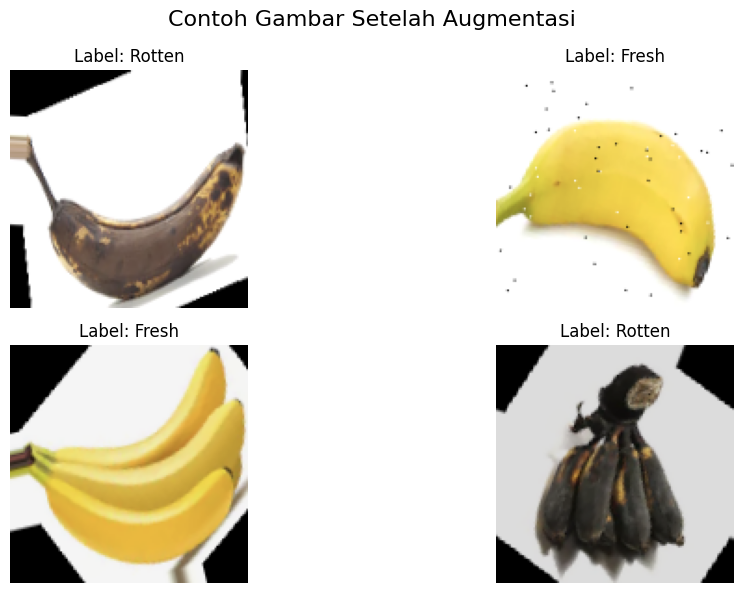


📈 STATISTIK AKHIR DATASET:
Train Generator: 119 batches × 32 = 3808 gambar
Validation Generator: 119 batches × 32 = 3808 gambar
Test Generator: 29 batches × 32 = 928 gambar


In [47]:

# --- 8. Tampilkan contoh augmentasi ---
plt.figure(figsize=(12, 6))
for i in range(4):
    batch = next(train_generator)
    img = batch[0][0]  # Ambil gambar pertama dari batch
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"Label: {'Fresh' if batch[1][0] == 0 else 'Rotten'}")
    plt.axis('off')
plt.suptitle("Contoh Gambar Setelah Augmentasi", fontsize=16)
plt.tight_layout()
plt.show()

# --- 9. Statistik akhir dataset ---
print("\n📈 STATISTIK AKHIR DATASET:")
print(f"Train Generator: {len(train_generator)} batches × {batch_size} = {len(train_generator)*batch_size} gambar")
print(f"Validation Generator: {len(val_generator)} batches × {batch_size} = {len(val_generator)*batch_size} gambar")
print(f"Test Generator: {len(test_generator)} batches × {batch_size} = {len(test_generator)*batch_size} gambar")

In [48]:
import os
import numpy as np

# Path folder
dataset_path = "dataset"
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

def count_class(folder, class_name):
    path = os.path.join(folder, class_name)
    if not os.path.exists(path):
        return 0
    return len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

# Hitung train
train_fresh = count_class(train_path, "freshbanana")
train_rotten = count_class(train_path, "rottenbanana")

# Hitung test
test_fresh = count_class(test_path, "freshbanana")
test_rotten = count_class(test_path, "rottenbanana")

print("📊 DISTRIBUSI KELAS ASLI:")
print(f"TRAIN SET:")
print(f"  Fresh: {train_fresh} ({train_fresh / (train_fresh + train_rotten) * 100:.1f}%)")
print(f"  Rotten: {train_rotten} ({train_rotten / (train_fresh + train_rotten) * 100:.1f}%)")

print(f"\nTEST SET:")
print(f"  Fresh: {test_fresh} ({test_fresh / (test_fresh + test_rotten) * 100:.1f}%)")
print(f"  Rotten: {test_rotten} ({test_rotten / (test_fresh + test_rotten) * 100:.1f}%)")

print(f"\nTOTAL:")
total_fresh = train_fresh + test_fresh
total_rotten = train_rotten + test_rotten
print(f"  Fresh: {total_fresh} ({total_fresh / (total_fresh + total_rotten) * 100:.1f}%)")
print(f"  Rotten: {total_rotten} ({total_rotten / (total_fresh + total_rotten) * 100:.1f}%)")

📊 DISTRIBUSI KELAS ASLI:
TRAIN SET:
  Fresh: 1581 (41.6%)
  Rotten: 2224 (58.4%)

TEST SET:
  Fresh: 381 (41.8%)
  Rotten: 530 (58.2%)

TOTAL:
  Fresh: 1962 (41.6%)
  Rotten: 2754 (58.4%)


## Modelling


In [51]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json

# === 1. KONFIGURASI ===
dataset_path = "dataset"
img_size = (128, 128)      # ← DIPERKECIL agar cepat!
batch_size = 32


In [52]:

# === 2. BUAT GENERATOR DATA ===
train_datagen = ImageDataGenerator(
    rescale=1./255.,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255.)

# Train Generator
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    classes=['freshbanana', 'rottenbanana'],
    shuffle=True,
    seed=42
)

# Validation Generator (ambil dari train folder, tapi kita split nanti via generator tidak langsung — tapi cukup pakai test sebagai validasi jika perlu)
# Karena dataset besar, kita bisa gunakan test sebagai validasi akhir, tapi untuk amannya, buat validation dari train:
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),  # Tetap dari train, tapi nanti kita evaluasi terpisah
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    classes=['freshbanana', 'rottenbanana'],
    shuffle=False,
    seed=42
)

# Test Generator
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    classes=['freshbanana', 'rottenbanana'],
    shuffle=False
)


Found 3805 images belonging to 2 classes.
Found 3805 images belonging to 2 classes.
Found 911 images belonging to 2 classes.


In [53]:
# === 3. HITUNG CLASS WEIGHTS ===
# Ambil label dari train generator
train_generator.reset()
labels = []
for i in range(len(train_generator)):
    _, batch_labels = next(train_generator)
    labels.extend(batch_labels.tolist())
train_generator.reset()  # Reset agar bisa dipakai lagi di fit()

class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}
print("⚖️ Class Weights:", class_weights_dict)


⚖️ Class Weights: {0: 1.2033523086654017, 1: 0.8554406474820144}


In [54]:
# === 4. BANGUN MODEL CNN SEDERHANA ===
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n🏗️ Arsitektur Model:")
model.summary()


c:\Users\ASUS\anaconda3\envs\PraktekPengolahanCitra\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🏗️ Arsitektur Model:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# === 5. LATIH MODEL ===
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

print("\n🚀 Mulai Pelatihan... (Harusnya lebih cepat dengan 128x128!)")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)



🚀 Mulai Pelatihan... (Harusnya lebih cepat dengan 128x128!)
Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 70s 568ms/step - accuracy: 0.9125 - loss: 0.2017 - val_accuracy: 0.9947 - val_loss: 0.0279 - learning_rate: 0.0010
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 66s 556ms/step - accuracy: 0.9882 - loss: 0.0463 - val_accuracy: 0.9861 - val_loss: 0.0416 - learning_rate: 0.0010
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 63s 525ms/step - accuracy: 0.9855 - loss: 0.0445 - val_accuracy: 0.9947 - val_loss: 0.0130 - learning_rate: 0.0010
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 56s 468ms/step - accuracy: 0.9884 - loss: 0.0376 - val_accuracy: 0.9966 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 61s 515ms/step - accuracy: 0.9779 - loss: 0.0748 - val_accuracy: 0.9798 - val_loss: 0.0487 - learning_rate: 0.0010
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 60s 501ms/step - accuracy: 0.9898 - loss: 0.0301 - val_accuracy: 0.9979 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 7/1

In [56]:
# === 6. EVALUASI ===
print("\n🔍 Evaluasi di Test Set...")
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"✅ Akurasi Test: {test_acc * 100:.2f}%")

# Prediksi untuk classification report
test_generator.reset()
y_true = test_generator.classes
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Fresh', 'Rotten']))


🔍 Evaluasi di Test Set...
✅ Akurasi Test: 99.89%
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step

📋 Classification Report:
              precision    recall  f1-score   support

       Fresh       1.00      1.00      1.00       381
      Rotten       1.00      1.00      1.00       530

    accuracy                           1.00       911
   macro avg       1.00      1.00      1.00       911
weighted avg       1.00      1.00      1.00       911



In [57]:
# === 7. SIMPAN MODEL & KONFIGURASI UNTUK STREAMLIT ===
import os
os.makedirs("model", exist_ok=True)

model.save("model/banana_cnn_model.h5")
config = {
    "class_names": ["freshbanana", "rottenbanana"],
    "img_size": [128, 128],
    "threshold": 0.5
}
with open("model/model_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("\n💾 Model dan konfigurasi disimpan di folder 'model/'")


💾 Model dan konfigurasi disimpan di folder 'model/'


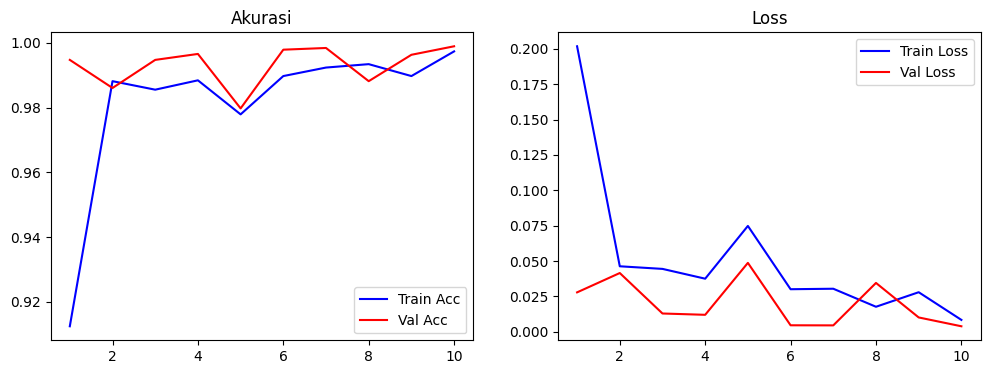

In [58]:
# === 8. PLOT HASIL PELATIHAN ===
plt.figure(figsize=(12, 4))
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Train Acc')
plt.plot(epochs, val_acc, 'r', label='Val Acc')
plt.title('Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Train Loss')
plt.plot(epochs, val_loss, 'r', label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

## Evaluasi

In [60]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step
📊 METRIK EVALUASI:
              precision    recall  f1-score   support

       Fresh       1.00      1.00      1.00       381
      Rotten       1.00      1.00      1.00       530

    accuracy                           1.00       911
   macro avg       1.00      1.00      1.00       911
weighted avg       1.00      1.00      1.00       911


✅ Akurasi: 99.89%


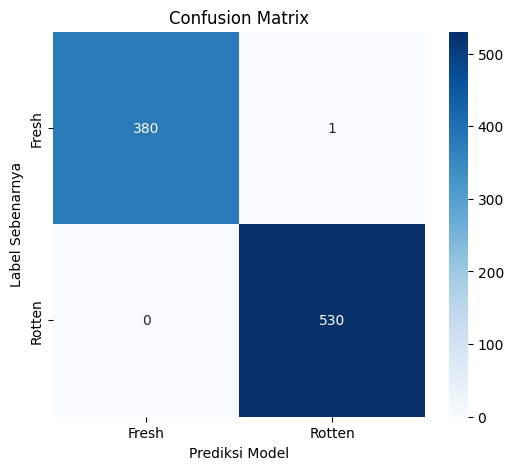


📈 ROC-AUC Score: 1.0000


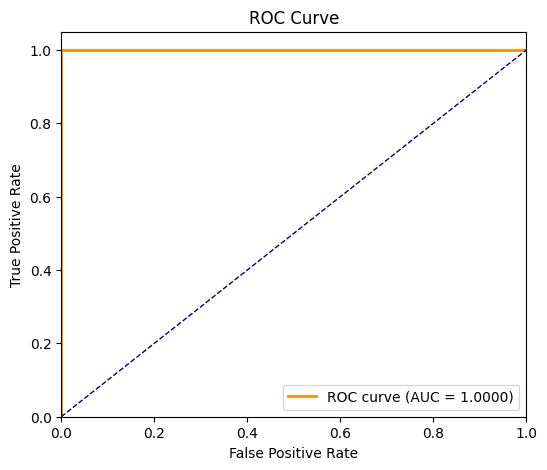


🔍 Jumlah Kesalahan Klasifikasi: 1
Contoh salah ke-1: Index 197 → Pred: Rotten, True: Fresh

💾 Hasil evaluasi disimpan di: model/evaluation_results.json


<Figure size 1200x800 with 0 Axes>

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.models import load_model

# --- 1. (Opsional) Muat model jika belum ada di memori ---
# model = load_model("model/banana_cnn_model.h5")

# --- 2. Reset generator dan dapatkan prediksi ---
test_generator.reset()
y_true = test_generator.classes  # Label sebenarnya (0=fresh, 1=rotten)

# Prediksi probabilitas
y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Threshold 0.5

# --- 3. Classification Report (Accuracy, Precision, Recall, F1) ---
print("📊 METRIK EVALUASI:")
print("="*50)
print(classification_report(y_true, y_pred, target_names=['Fresh', 'Rotten']))

# Hitung accuracy manual (opsional)
accuracy = np.mean(y_true == y_pred)
print(f"\n✅ Akurasi: {accuracy * 100:.2f}%")

# --- 4. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fresh', 'Rotten'],
            yticklabels=['Fresh', 'Rotten'])
plt.title('Confusion Matrix')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

# --- 5. ROC-AUC dan Kurva ROC ---
auc_score = roc_auc_score(y_true, y_pred_prob)
print(f"\n📈 ROC-AUC Score: {auc_score:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# --- 6. ANALISIS KESALAHAN (jika ada) ---
errors = np.where(y_true != y_pred)[0]
print(f"\n🔍 Jumlah Kesalahan Klasifikasi: {len(errors)}")

if len(errors) > 0:
    # Tampilkan 4 contoh kesalahan
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(errors[:4]):
        # Ambil path gambar dari generator (agak tricky, jadi kita load ulang)
        # Alternatif: simpan path saat evaluasi — tapi untuk sederhana, kita skip visual error dulu jika sulit
        print(f"Contoh salah ke-{i+1}: Index {idx} → Pred: {'Rotten' if y_pred[idx] == 1 else 'Fresh'}, True: {'Rotten' if y_true[idx] == 1 else 'Fresh'}")
else:
    print("✅ Tidak ada kesalahan klasifikasi pada test set!")

# --- 7. Simpan hasil evaluasi (opsional) ---
results = {
    "accuracy": float(accuracy),
    "roc_auc": float(auc_score),
    "classification_report": classification_report(y_true, y_pred, target_names=['Fresh', 'Rotten'], output_dict=True)
}

import json
with open("model/evaluation_results.json", "w") as f:
    json.dump(results, f, indent=4)
print("\n💾 Hasil evaluasi disimpan di: model/evaluation_results.json")